What's being asked:

1. PD model: train a classifier that outputs the probability a borrower defaults

2. Expected loss function: calculate how much money the bank loses on that loan using the probability 

Expected loss formula: PD x LGD x EAD 

PD - Probability of default

LGD - Loss Given Default    -   % of loan loss if default

EAD - Exposure At Default   -   How much is owed

(10000, 8)

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0



Default distribution:


default
0    8149
1    1851
Name: count, dtype: int64

default
0    0.815
1    0.185
Name: proportion, dtype: float64

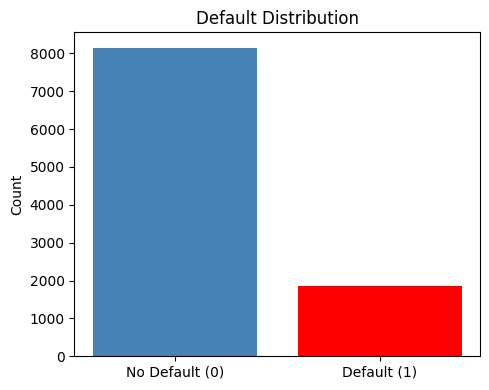

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve)

df = pd.read_csv('Loan_Data.csv')

display(df.shape)
display(df.head())
# display(df.dtypes)

# # check for missing values
# print("\nMissing Values:")
# display(df.isnull().sum())

# how many people defaulted vs who didn't
print("\nDefault distribution:")
display(df['default'].value_counts())
display(df['default'].value_counts(normalize = True).round(3))

# plot it
plt.figure(figsize=(5,4))
# plt.bar(x_labels, heights)
plt.bar(['No Default (0)', 'Default (1)'], 
        df['default'].value_counts().sort_index(),
        color = ['steelblue', 'red'])
plt.title("Default Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig('default_distribution.png', dpi=150)
plt.show()

block 2: preprocessing

- drop customer id (not a feature)

- split into train/test BEFORE scaling to avoid data leakage

- scale feature so fico_score(300-850) doesn't over power income

In [45]:
df = df.drop(columns = ['customer_id'])

X = df.drop(columns = ['default'])
y = df['default']

X_train, y_train, X_test, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# fit scaler to train only, apply to both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

KeyError: "['customer_id'] not found in axis"